# ARIMA → SARIMA, Holt-Winters, Theta


## 1. Импорты и загрузка

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.forecasting.theta import ThetaModel

warnings.simplefilter('ignore')  # после импортов statsmodels
plt.rcParams['figure.figsize'] = (14, 5)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

df = pd.read_csv('TS (1) (1).csv')
df['Time'] = pd.to_datetime(df['Time'], format='%m/%d/%y %H:%M')
s = df.set_index('Time').sort_index()['Users'].asfreq('h')

# Сбои: нули и обрывки (1111, 1931, 7930...) -> NaN, заполняем средним того же часа вчера и завтра
s[(s < 12000) | s.isna()] = np.nan
s = s.fillna((s.shift(24) + s.shift(-24)) / 2).interpolate()

y = np.log(s)  # лог: стабилизирует амплитуду суточных колебаний

TRAIN_FROM = '2017-02-20'  # после аномального всплеска 10-19 февраля
TEST_START = '2017-04-01'
y_train = y[TRAIN_FROM:pd.Timestamp(TEST_START) - pd.Timedelta('1h')]
y_test = y[TEST_START:]
test = np.exp(y_test)
H = len(y_test)
print(f'train: {y_train.index.min()} — {y_train.index.max()} ({len(y_train)} ч)')
print(f'test : {y_test.index.min()} — {y_test.index.max()} ({H} ч)')

train: 2017-02-20 00:00:00 — 2017-03-31 23:00:00 (960 ч)
test : 2017-04-01 00:00:00 — 2017-04-20 09:00:00 (466 ч)


## 2. Вспомогательные функции

In [ ]:
def adf_test(series, name):
    p = adfuller(series.dropna(), autolag='AIC')[1]
    print(f'{name:35s} p-value={p:.4f} -> {"стационарен" if p < 0.05 else "НЕ стационарен"}')


def significant_lags(series, nlags=50):
    """Лаги, где ACF / PACF выходят за 95% доверительную полосу"""
    x = series.dropna()
    a, a_ci = acf(x, nlags=nlags, alpha=0.05)
    p, p_ci = pacf(x, nlags=nlags, alpha=0.05)
    a_sig = [k for k in range(1, nlags + 1) if abs(a[k]) > a_ci[k, 1] - a[k]]
    p_sig = [k for k in range(1, nlags + 1) if abs(p[k]) > p_ci[k, 1] - p[k]]
    print('Значимые лаги ACF :', a_sig)
    print('Значимые лаги PACF:', p_sig)


def plot_acf_pacf(series, title, lags=50):
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    plot_acf(series.dropna(), lags=lags, ax=ax[0]); ax[0].set_title(f'ACF: {title}')
    plot_pacf(series.dropna(), lags=lags, ax=ax[1], method='ywm'); ax[1].set_title(f'PACF: {title}')
    plt.tight_layout(); plt.show()


def metrics(actual, forecast):
    a, f = np.asarray(actual), np.asarray(forecast)
    e = a - f
    return {'MAE': np.mean(np.abs(e)), 'RMSE': np.sqrt(np.mean(e ** 2)), 'MAPE, %': np.mean(np.abs(e) / a) * 100}


T0 = pd.Timestamp('2017-01-01')

def fourier(index, period, K):
    """K пар синусов/косинусов с периодом period часов (для недельной сезонности)."""
    t = ((index - T0) / pd.Timedelta('1h')).values
    cols = {}
    for k in range(1, K + 1):
        cols[f'sin{period}_{k}'] = np.sin(2 * np.pi * k * t / period)
        cols[f'cos{period}_{k}'] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols, index=index)


def rolling_statespace(res, future, exog_fn=None, step=24):
    """Скользящий прогноз на step часов для ARIMA/SARIMA: параметры фиксированы,
    после каждого шага в модель добавляются фактические значения (res.append)."""
    preds, cur = [], res
    for o in range(0, len(future), step):
        idx = future.index[o:o + step]
        ex = exog_fn(idx) if exog_fn else None
        preds.append(cur.forecast(len(idx), exog=ex).values)
        cur = cur.append(future.iloc[o:o + step], exog=ex)
    return pd.Series(np.concatenate(preds), index=future.index)


def rolling_refit(history, future, fit_predict, step=24):
    """Скользящий прогноз для HW/Theta: модель переобучается на всей известной истории каждые step часов."""
    preds = []
    for o in range(0, len(future), step):
        idx = future.index[o:o + step]
        hist = pd.concat([history, future.iloc[:o]])
        preds.append(np.asarray(fit_predict(hist, len(idx))))
    return pd.Series(np.concatenate(preds), index=future.index)

## 3. ARIMA, шаг 1: порядок разности d (ADF-тест)

In [ ]:
adf_test(y_train, 'log-ряд')
adf_test(y_train.diff(), '1-я разность')


log-ряд                             p-value=0.5190 -> НЕ стационарен
1-я разность                        p-value=0.0000 -> стационарен


## 4. ARIMA, шаг 2: p и q по ACF / PACF разности

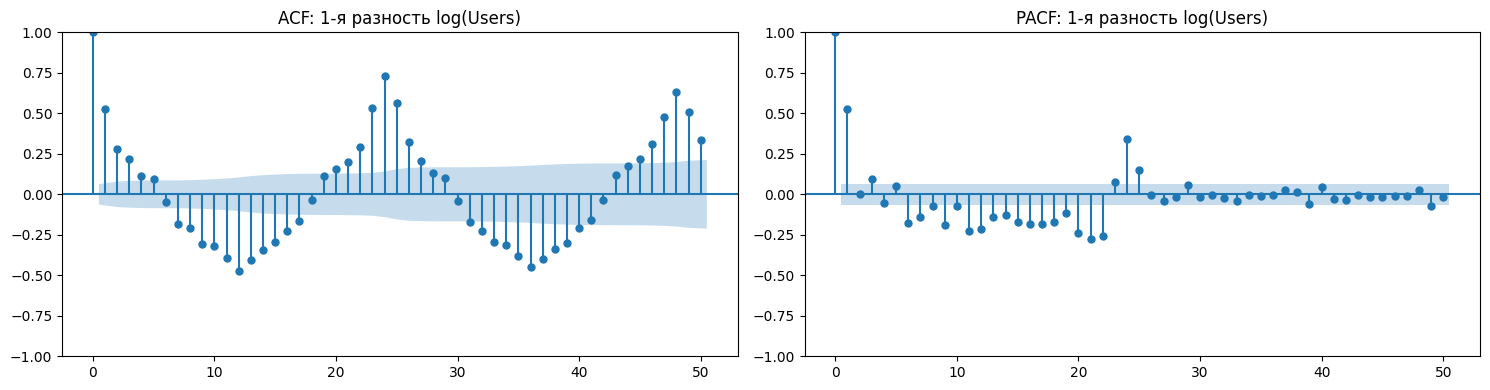

Значимые лаги ACF : [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 20, 21, 22, 23, 24, 25, 26, 27, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 45, 46, 47, 48, 49, 50]
Значимые лаги PACF: [1, 3, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 29, 39, 49]


In [4]:
plot_acf_pacf(y_train.diff(), '1-я разность log(Users)', lags=50)
significant_lags(y_train.diff(), nlags=50)
# Как читать:
#   PACF резко обрывается после лага k -> AR(p), p = k
#   ACF  резко обрывается после лага k -> MA(q), q = k
#   оба затухают плавно -> ARMA, берём небольшие p и q
# Точек много, поэтому формально значимыми выходят десятки лагов: смотри на самые высокие пики.
# Здесь PACF: крупные пики на 1-3, дальше мелочь -> p = 1..3; ACF затухает -> q = 0..2.
# Пики на 24, 48 - это суточная сезонность. Обычная ARIMA её не моделирует, к ней вернёмся в SARIMA.

## 5. ARIMA, шаг 3: кандидаты рядом с тем, что видно на графиках, сравниваем по AIC

In [5]:
candidates = [(1, 1, 0), (2, 1, 0), (3, 1, 0), (1, 1, 1), (2, 1, 1), (2, 1, 2), (3, 1, 1)]
rows = []
for order in candidates:
    r = ARIMA(y_train, order=order).fit()
    rows.append({'order': order, 'AIC': r.aic, 'BIC': r.bic})
arima_table = pd.DataFrame(rows).sort_values('AIC')
print(arima_table.round(1))

ARIMA_ORDER = arima_table.iloc[0]['order']
print('Выбрано ARIMA', ARIMA_ORDER)

       order     AIC     BIC
6  (3, 1, 1) -2126.1 -2101.8
5  (2, 1, 2) -2124.5 -2100.2
2  (3, 1, 0) -2120.6 -2101.1
4  (2, 1, 1) -2118.3 -2098.9
0  (1, 1, 0) -2115.4 -2105.7
3  (1, 1, 1) -2113.4 -2098.8
1  (2, 1, 0) -2113.4 -2098.8
Выбрано ARIMA (3, 1, 1)


## 6. ARIMA, шаг 4: обучение и диагностика остатков

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0533      0.134     -0.398      0.690      -0.316       0.209
ar.L2          0.2503      0.077      3.251      0.001       0.099       0.401
ar.L3          0.1098      0.028      3.864      0.000       0.054       0.165
ma.L1          0.5857      0.132      4.451      0.000       0.328       0.844
sigma2         0.0063      0.000     26.208      0.000       0.006       0.007


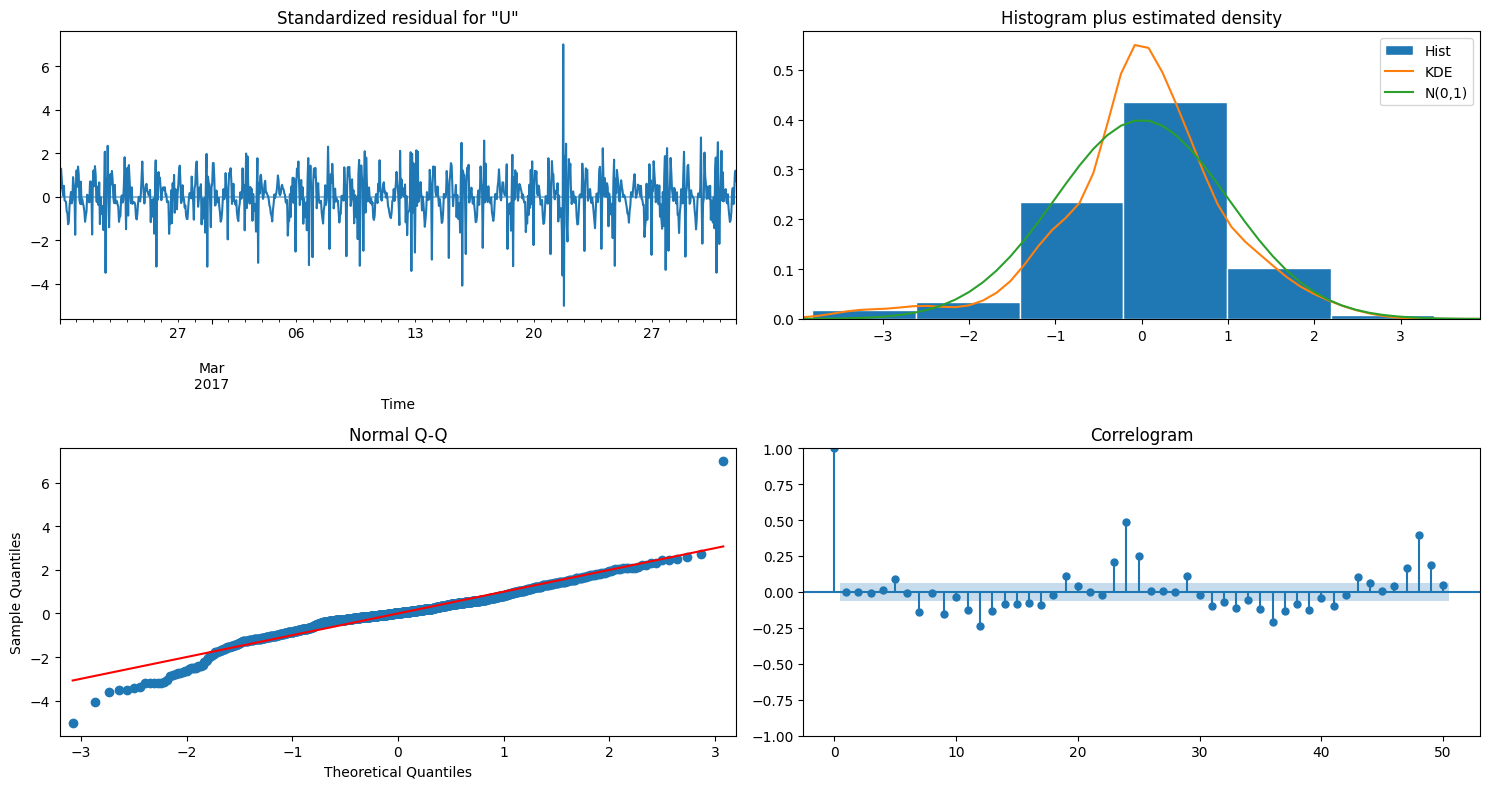

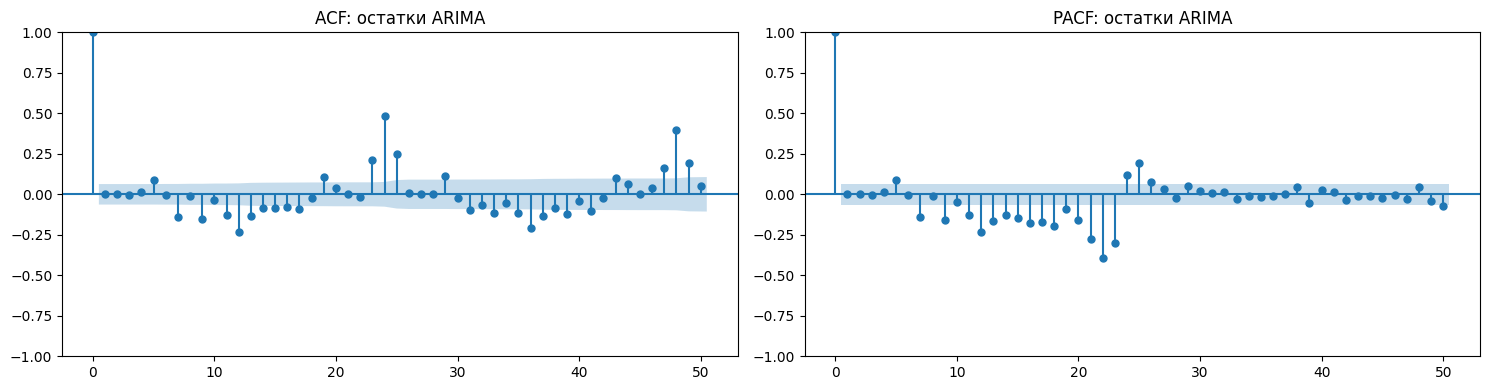

In [ ]:
arima = ARIMA(y_train, order=ARIMA_ORDER).fit()
print(arima.summary().tables[1])

arima.plot_diagnostics(figsize=(15, 8), lags=50)
plt.tight_layout(); plt.show()
plot_acf_pacf(arima.resid[1:], 'остатки ARIMA', lags=50)


## 7. ARIMA, шаг 5: прогноз

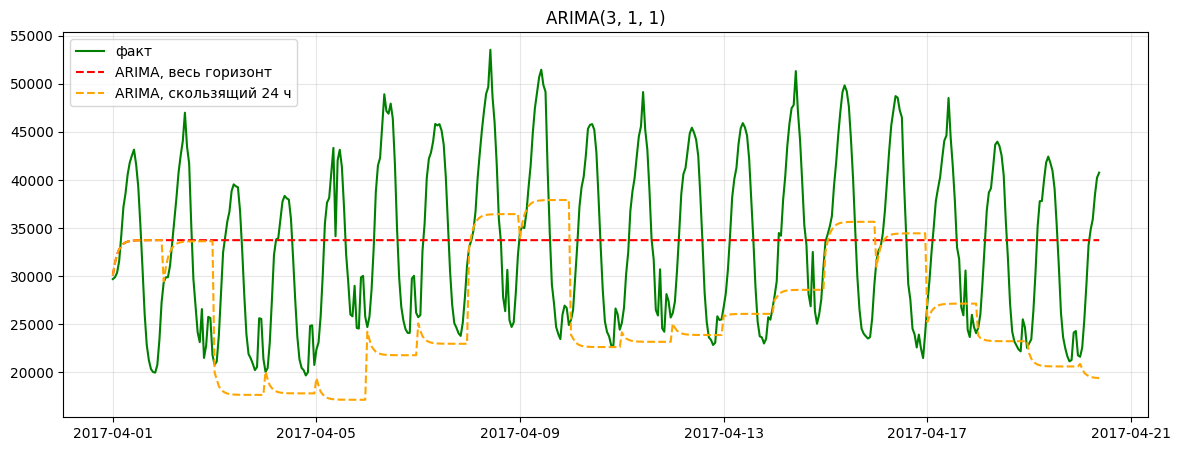

Весь горизонт: {'MAE': 7478.88, 'RMSE': 8530.71, 'MAPE, %': 24.44}
Скользящий 24ч: {'MAE': 9525.12, 'RMSE': 11922.61, 'MAPE, %': 26.93}


In [7]:
arima_full = np.exp(arima.forecast(H))                    # один прогноз на весь тест
arima_roll = np.exp(rolling_statespace(arima, y_test))    # скользящий на 24 ч

fig, ax = plt.subplots()
ax.plot(test, color='green', label='факт')
ax.plot(arima_full, 'r--', label='ARIMA, весь горизонт')
ax.plot(arima_roll, color='orange', ls='--', label='ARIMA, скользящий 24 ч')
ax.set_title(f'ARIMA{ARIMA_ORDER}'); ax.legend(); ax.grid(alpha=0.3); plt.show()
print('Весь горизонт:', {k: round(v, 2) for k, v in metrics(test, arima_full).items()})
print('Скользящий 24ч:', {k: round(v, 2) for k, v in metrics(test, arima_roll).items()})

## 8. SARIMA, шаг 1: сезонная разность D (m = 24)

In [8]:
adf_test(y_train.diff(24), 'сезонная разность (24)')
adf_test(y_train.diff(24).diff(), 'сезонная + 1-я разность')
# После сезонной разности ряд уже стационарен -> D = 1, d = 0.
# Если взять ещё и d = 1 (двойное дифференцирование), длинный прогноз уходит по случайному тренду.

сезонная разность (24)              p-value=0.0000 -> стационарен
сезонная + 1-я разность             p-value=0.0000 -> стационарен


## 9. SARIMA, шаг 2: сезонные P, Q (смотрим лаги 24, 48, 72) и обычные p, q (лаги 1..23)

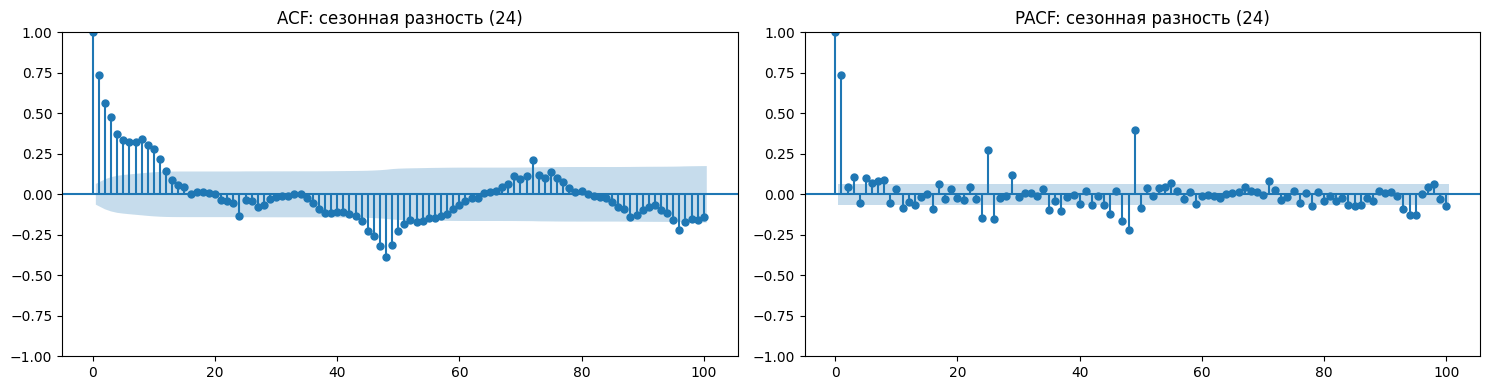

Значимые лаги ACF : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 44, 45, 46, 47, 48, 49, 50, 51, 53, 54, 72, 96]
Значимые лаги PACF: [1, 3, 5, 6, 7, 8, 11, 13, 16, 17, 24, 25, 26, 29, 35, 37, 40, 42, 44, 45, 47, 48, 49, 50, 55, 59, 71, 76, 78, 84, 85, 86, 93, 94, 95, 98, 100]


In [9]:
y_sd = y_train.diff(24)
plot_acf_pacf(y_sd, 'сезонная разность (24)', lags=100)
significant_lags(y_sd, nlags=100)
# Сезонная часть: ACF - один большой отрицательный пик на 24, PACF затухает на 24, 48, 72 -> Q = 1, P = 0
# Обычная часть: в PACF крупные пики только на первых 1-2 лагах, ACF затухает плавно -> p = 1..2, q = 0..1
# (как и для ARIMA, мелкие «значимые» лаги дальше - эффект большой выборки)

## 10. SARIMA, шаг 3: недельная сезонность (168 ч) через ряды Фурье

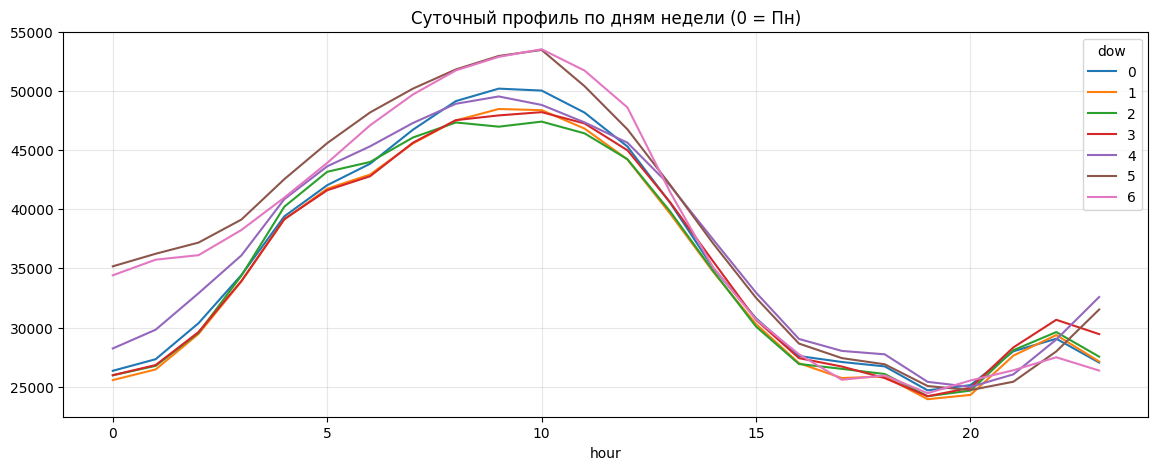

In [ ]:

prof = s[TRAIN_FROM:].to_frame('Users')
prof['hour'], prof['dow'] = prof.index.hour, prof.index.dayofweek
prof.pivot_table(index='hour', columns='dow', values='Users').plot(title='Суточный профиль по дням недели (0 = Пн)')
plt.grid(alpha=0.3); plt.show()

K_WEEK = 6
X_week = lambda idx: fourier(idx, 168, K_WEEK)

## 11. SARIMA, шаг 4: кандидаты по графикам, сравнение по AIC (несколько минут)

In [11]:
SEASONAL = (0, 1, 1, 24)
rows = []
for order in [(1, 0, 0), (2, 0, 0), (1, 0, 1), (2, 0, 1)]:
    r = SARIMAX(y_train, exog=X_week(y_train.index), order=order, seasonal_order=SEASONAL).fit(disp=False, maxiter=200)
    rows.append({'order': order, 'seasonal': SEASONAL, 'AIC': r.aic, 'BIC': r.bic})
sarima_table = pd.DataFrame(rows).sort_values('AIC')
print(sarima_table.round(1))

SARIMA_ORDER = sarima_table.iloc[0]['order']
print('Выбрано SARIMA', SARIMA_ORDER, SEASONAL, f'+ Фурье K={K_WEEK}')

       order       seasonal     AIC     BIC
3  (2, 0, 1)  (0, 1, 1, 24) -2845.0 -2762.7
2  (1, 0, 1)  (0, 1, 1, 24) -2840.2 -2762.7
1  (2, 0, 0)  (0, 1, 1, 24) -2837.4 -2759.9
0  (1, 0, 0)  (0, 1, 1, 24) -2826.8 -2754.1
Выбрано SARIMA (2, 0, 1) (0, 1, 1, 24) + Фурье K=6


## 12. SARIMA, шаг 5: обучение, диагностика, прогноз

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sin168_1      -0.0254      0.010     -2.599      0.009      -0.045      -0.006
cos168_1       0.0512      0.009      5.748      0.000       0.034       0.069
sin168_2      -0.0185      0.009     -2.039      0.041      -0.036      -0.001
cos168_2       0.0187      0.009      2.123      0.034       0.001       0.036
sin168_3      -0.0013      0.008     -0.153      0.879      -0.018       0.015
cos168_3       0.0053      0.009      0.600      0.549      -0.012       0.023
sin168_4       0.0051      0.008      0.635      0.525      -0.011       0.021
cos168_4       0.0060      0.009      0.683      0.495      -0.011       0.023
sin168_5       0.0197      0.008      2.426      0.015       0.004       0.036
cos168_5      -0.0031      0.008     -0.375      0.708      -0.019       0.013
sin168_6       0.0281      0.008      3.439      0.0

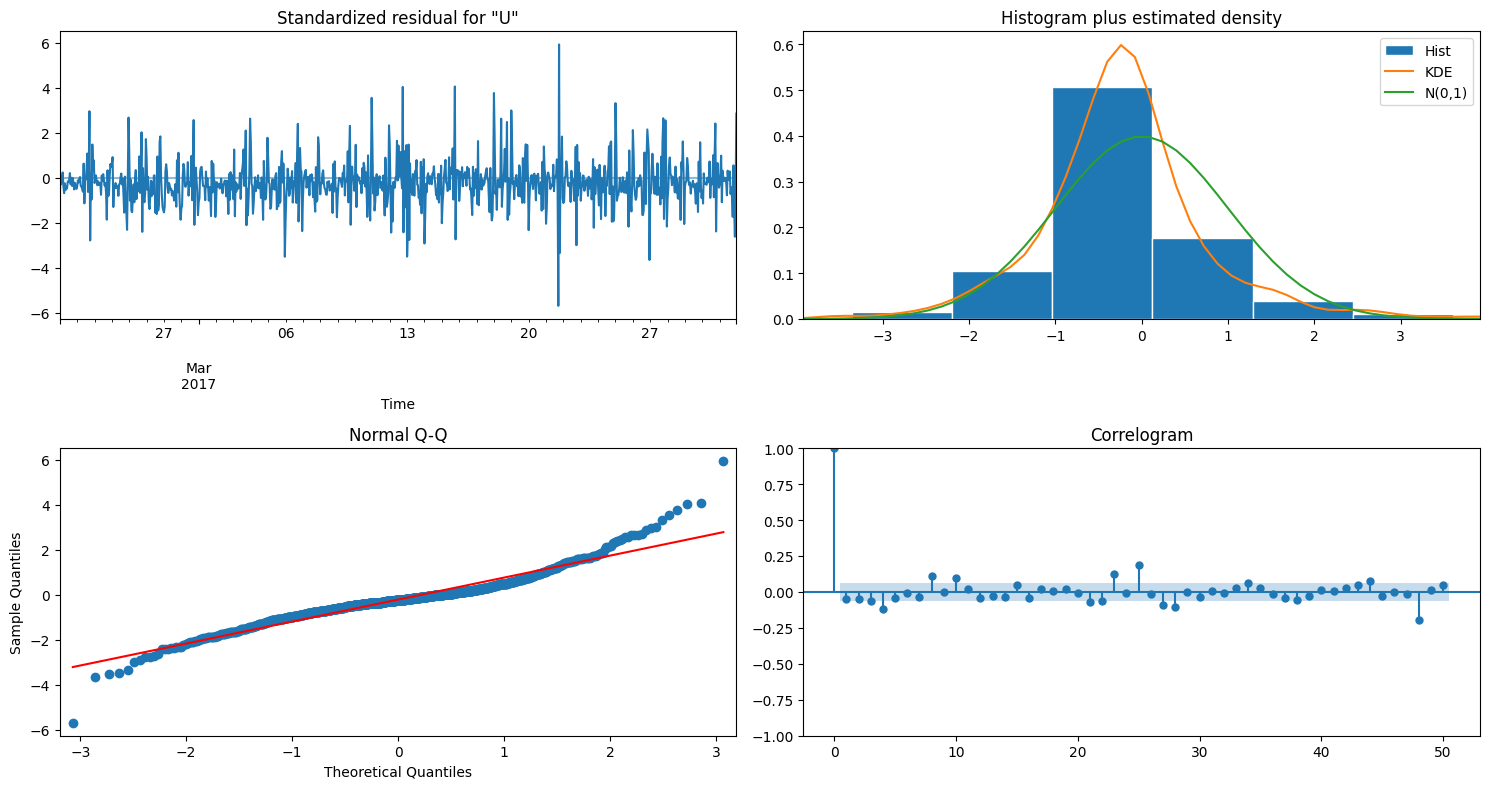

In [12]:
sarima = SARIMAX(y_train, exog=X_week(y_train.index), order=SARIMA_ORDER,
                 seasonal_order=SEASONAL).fit(disp=False, maxiter=200)
print(sarima.summary().tables[1])
sarima.plot_diagnostics(figsize=(15, 8), lags=50)
plt.tight_layout(); plt.show()

sarima_fc = sarima.get_forecast(H, exog=X_week(y_test.index))
sarima_full = np.exp(sarima_fc.predicted_mean)
sarima_ci = np.exp(sarima_fc.conf_int())
sarima_roll = np.exp(rolling_statespace(sarima, y_test, exog_fn=X_week))

## 13. Holt-Winters (тройное экспоненциальное сглаживание)

In [13]:
# уровень + затухающий тренд + сезонность. Сезонность только одна: берём суточную (24).
def hw_predict(hist, h):
    m = ExponentialSmoothing(hist[TRAIN_FROM:], trend='add', damped_trend=True,
                             seasonal='add', seasonal_periods=24).fit()
    return m.forecast(h).values

hw_full = pd.Series(np.exp(hw_predict(y_train, H)), index=y_test.index)
hw_roll = np.exp(rolling_refit(y_train, y_test, hw_predict))

## 14. Theta

In [14]:
# Убирает сезонность (период 168 - неделя, она включает и суточный цикл),
# прогноз = простое экспоненциальное сглаживание + доля линейного тренда (чем больше theta, тем больше тренда),
# затем возвращает сезонность.
def theta_predict(hist, h):
    return ThetaModel(hist[TRAIN_FROM:], period=168, method='additive').fit().forecast(h, theta=3).values

theta_full = pd.Series(np.exp(theta_predict(y_train, H)), index=y_test.index)
theta_roll = np.exp(rolling_refit(y_train, y_test, theta_predict))

## 15. Сравнение: таблица

In [15]:
naive_day = np.exp(y.shift(24)[y_test.index])    # «как вчера в этот час»
naive_week = np.exp(y.shift(168)[y_test.index])  # «как неделю назад»
naive_week_full = pd.Series(np.tile(np.exp(y_train.iloc[-168:]).values, H // 168 + 1)[:H], index=y_test.index)

full = {'ARIMA': arima_full, 'SARIMA + Фурье': sarima_full, 'Holt-Winters': hw_full,
        'Theta': theta_full, 'Наивный (неделю назад)': naive_week_full}
roll = {'ARIMA': arima_roll, 'SARIMA + Фурье': sarima_roll, 'Holt-Winters': hw_roll,
        'Theta': theta_roll, 'Наивный (вчера)': naive_day, 'Наивный (неделю назад)': naive_week}

res_full = pd.DataFrame({k: metrics(test, v) for k, v in full.items()}).T
res_roll = pd.DataFrame({k: metrics(test, v) for k, v in roll.items()}).T
summary = pd.concat({'Весь горизонт': res_full, 'Скользящий 24 ч': res_roll}, axis=1)
print(summary.round(2))

                       Весь горизонт                  Скользящий 24 ч                  
                                 MAE     RMSE MAPE, %             MAE      RMSE MAPE, %
ARIMA                        7478.88  8530.71   24.44         9525.12  11922.61   26.93
SARIMA + Фурье               3175.79  3738.14    9.52         1976.26   2543.95    6.09
Holt-Winters                 2658.16  3456.35    8.49         2809.27   3350.02    8.73
Theta                        5004.90  5681.98   14.82         2122.63   2802.61    6.47
Наивный (неделю назад)       3189.14  3728.32    9.64         3165.29   3861.03    9.67
Наивный (вчера)                  NaN      NaN     NaN         2061.29   2859.04    6.54


## 16. Сравнение: графики

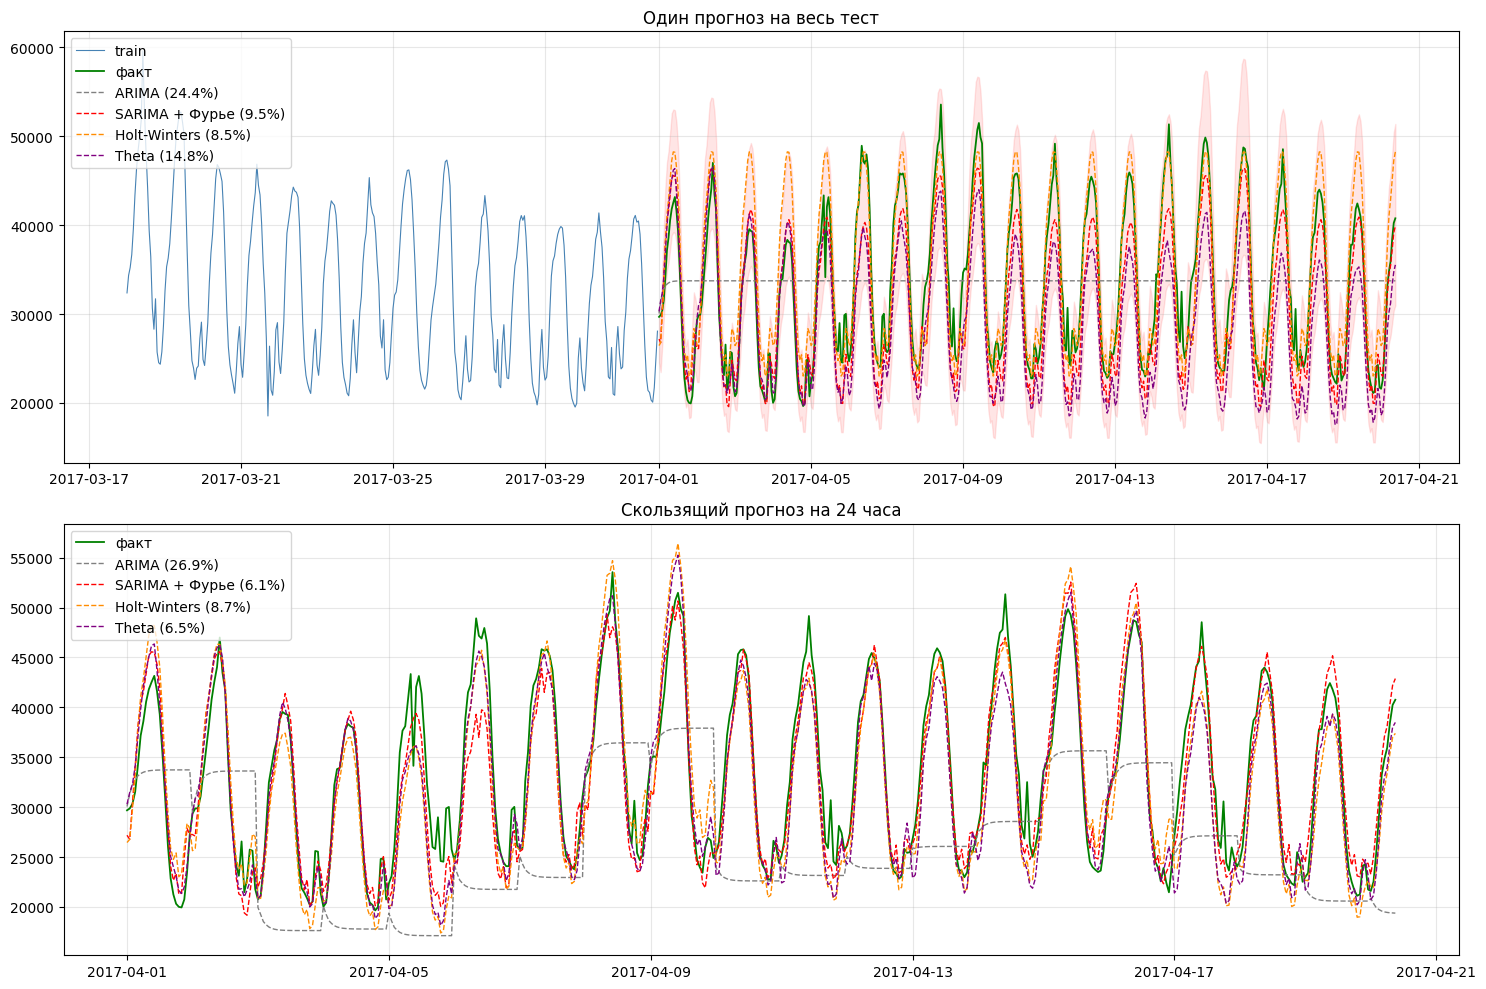

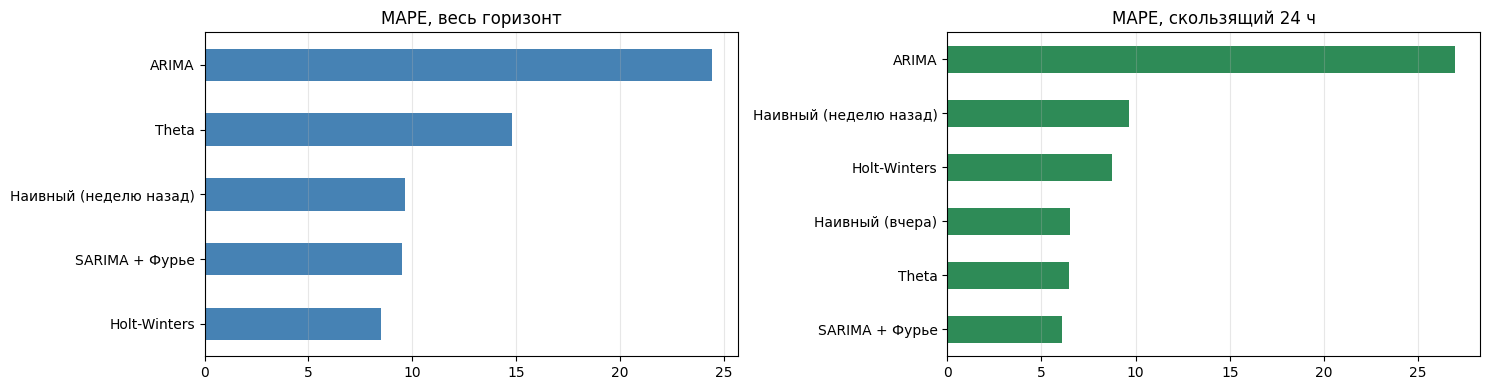

In [16]:
colors = {'ARIMA': 'gray', 'SARIMA + Фурье': 'red', 'Holt-Winters': 'darkorange', 'Theta': 'purple'}
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

axes[0].plot(np.exp(y_train['2017-03-18':]), color='steelblue', lw=0.8, label='train')
axes[0].plot(test, color='green', lw=1.3, label='факт')
for name, c in colors.items():
    axes[0].plot(full[name], color=c, ls='--', lw=1, label=f"{name} ({res_full.loc[name, 'MAPE, %']:.1f}%)")
axes[0].fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color='red', alpha=0.1)
axes[0].set_title('Один прогноз на весь тест'); axes[0].legend(loc='upper left'); axes[0].grid(alpha=0.3)

axes[1].plot(test, color='green', lw=1.3, label='факт')
for name, c in colors.items():
    axes[1].plot(roll[name], color=c, ls='--', lw=1, label=f"{name} ({res_roll.loc[name, 'MAPE, %']:.1f}%)")
axes[1].set_title('Скользящий прогноз на 24 часа'); axes[1].legend(loc='upper left'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
res_full['MAPE, %'].sort_values().plot.barh(ax=axes[0], color='steelblue', title='MAPE, весь горизонт')
res_roll['MAPE, %'].sort_values().plot.barh(ax=axes[1], color='seagreen', title='MAPE, скользящий 24 ч')
for a in axes:
    a.grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.show()